## Olist E-Commerce — EDA & Customer Segmentation
This notebook performs exploratory data analysis and k-means clustering on the RFM table generated in 01_rfm_sql. Customers are segmented into distinct groups based on purchasing behaviour to support targeted marketing decisions.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ERROR: Error in parse(text = input): <text>:1:6: unexpected symbol
1: from google.colab
         ^


In [ ]:
data_path <- '/content/drive/MyDrive/ecommerce-segmentation/data/'
rfm <- read.csv(paste0(data_path, 'rfm_output.csv'))
head(rfm)

,customer_unique_id,customer_city,customer_state,recency,frequency,monetary
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>
1,0a0a92112bd4c708ca5fde585afaa872,rio de janeiro,RJ,383,1,13664.08
2,da122df9eeddfedc1dc1f5349a1a690c,araruama,RJ,564,2,7571.63
3,763c8b1c9c68a0229c42c9fc6f662b93,vila velha,ES,94,1,7274.88
4,dc4802a71eae9be1dd28f5d788ceb526,campo grande,MS,612,1,6929.31
5,459bef486812aa25204be022145caa62,vitoria,ES,84,1,6922.21
6,ff4159b92c40ebe40454e3e6a7c35ed6,marilia,SP,511,1,6726.66


In [ ]:
install.packages(c('tidyverse', 'ggplot2', 'cluster', 'factoextra'))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘lazyeval’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘crosstalk’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘corrplot’, ‘viridis’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘irlba’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘dendextend’, ‘FactoMineR’, ‘ggpubr’, ‘ggrepel’




In [ ]:
library(tidyverse)
library(ggplot2)
library(cluster)
library(factoextra)

data_path <- '/content/drive/MyDrive/ecommerce-segmentation/data/'
rfm <- read.csv(paste0(data_path, 'rfm_output.csv'))

glimpse(rfm)
summary(rfm[, c('recency', 'frequency', 'monetary')])

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/



Rows: 93,470
Columns: 6
$ customer_unique_id <chr> "0a0a92112bd4c708ca5fde585afaa872", "da122df9eeddfe…
$ customer_city      <chr> "rio de janeiro", "araruama", "vila velha", "campo …
$ customer_state     <chr> "RJ", "RJ", "ES", "MS", "ES", "SP", "MG", "SP", "PB…
$ recency            <int> 383, 564, 94, 612, 84, 511, 327, 547, 117, 70, 75, …
$ frequency          <int> 1, 2, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1, 1, 1, …
$ monetary           <dbl> 13664.08, 7571.63, 7274.88, 6929.31, 6922.21, 6726.…


    recency        frequency         monetary       
 Min.   : 49.0   Min.   : 1.000   Min.   :    9.59  
 1st Qu.:163.0   1st Qu.: 1.000   1st Qu.:   63.00  
 Median :268.0   Median : 1.000   Median :  107.78  
 Mean   :286.6   Mean   : 1.032   Mean   :  165.00  
 3rd Qu.:395.0   3rd Qu.: 1.000   3rd Qu.:  182.29  
 Max.   :744.0   Max.   :15.000   Max.   :13664.08  

### Exploratory Data Analysis
The summary reveals that the majority of customers have a frequency of 1, indicating a largely one-time buyer base. Monetary values are heavily right-skewed with significant outliers, requiring log transformation before clustering.

In [ ]:
# Remove extreme outliers (top 1% monetary)
rfm_clean <- rfm %>%
  filter(monetary < quantile(monetary, 0.99))

# Log transform to reduce skew
rfm_clean <- rfm_clean %>%
  mutate(
    log_monetary = log1p(monetary),
    log_frequency = log1p(frequency)
  )

cat("Rows after removing outliers:", nrow(rfm_clean), "\n")
cat("Rows removed:", nrow(rfm) - nrow(rfm_clean), "\n")

Rows after removing outliers: 92535 
Rows removed: 935 


### Visualise Distributions
Before clustering we visualise the distribution of each RFM variable to understand the shape of the data.

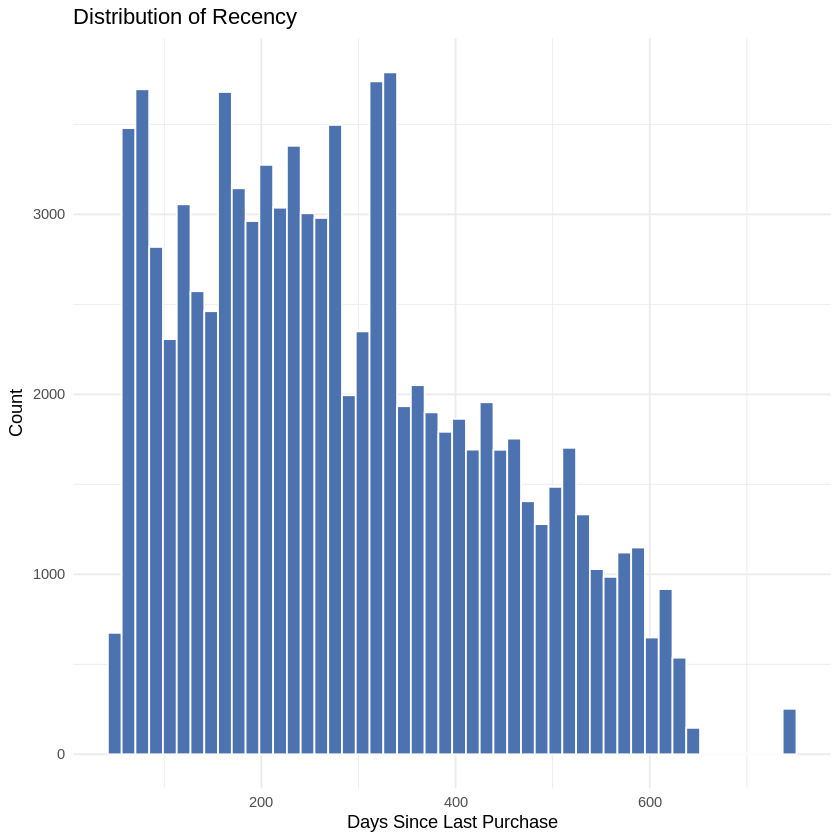

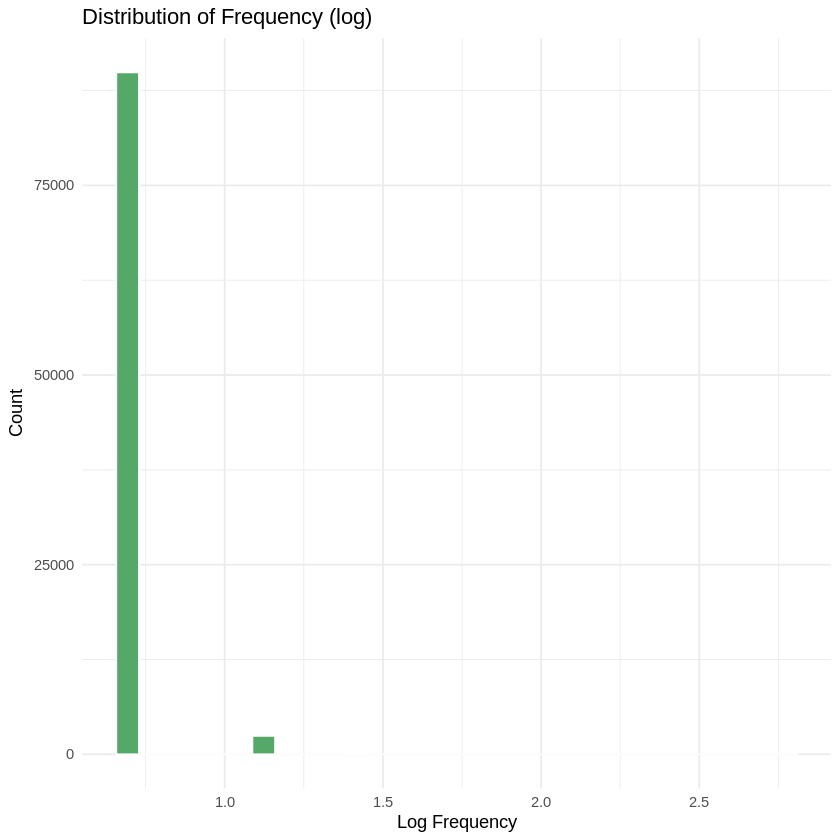

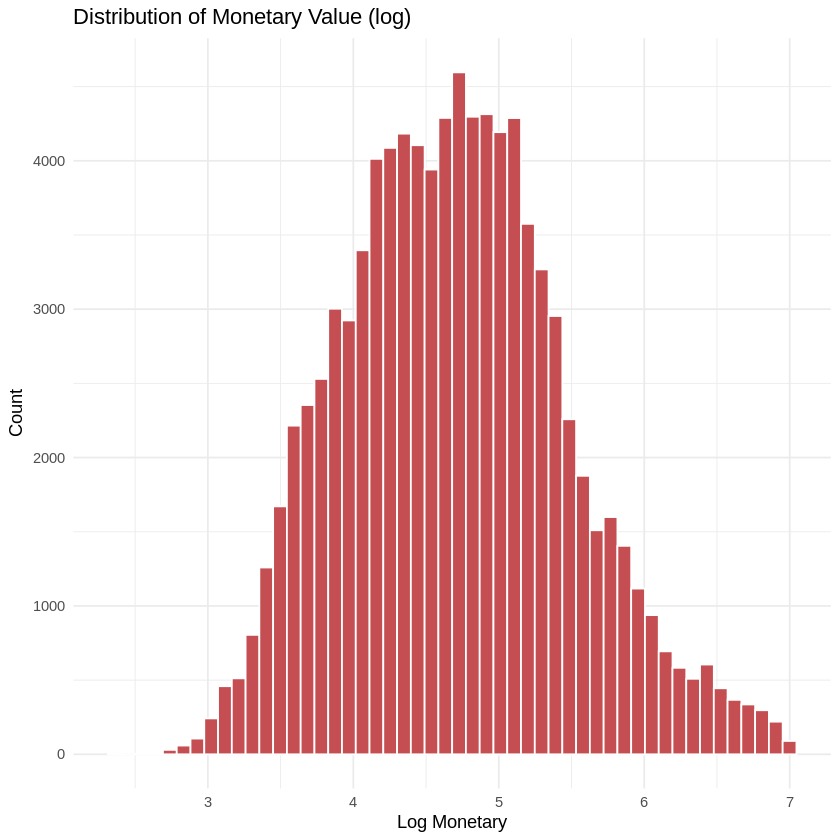

In [ ]:
p1 <- ggplot(rfm_clean, aes(x = recency)) +
  geom_histogram(bins = 50, fill = '#4C72B0', color = 'white') +
  labs(title = 'Distribution of Recency', x = 'Days Since Last Purchase', y = 'Count') +
  theme_minimal()

p2 <- ggplot(rfm_clean, aes(x = log_frequency)) +
  geom_histogram(bins = 30, fill = '#55A868', color = 'white') +
  labs(title = 'Distribution of Frequency (log)', x = 'Log Frequency', y = 'Count') +
  theme_minimal()

p3 <- ggplot(rfm_clean, aes(x = log_monetary)) +
  geom_histogram(bins = 50, fill = '#C44E52', color = 'white') +
  labs(title = 'Distribution of Monetary Value (log)', x = 'Log Monetary', y = 'Count') +
  theme_minimal()

p1
p2
p3

### Interpretation

**Recency**: Right-skewed distribution with most customers having purchased within 200 days, and a long tail of dormant customers extending to 700+ days. This suggests a sizeable inactive customer base worth targeting for re-engagement.

**Frequency (log)**: Extremely concentrated at 1 — the vast majority of customers made only a single purchase. Repeat buyers are a very small minority, making frequency a weak differentiator for clustering.

**Monetary (log)**: After log transformation the distribution is approximately bell-shaped and centred around log(4.5), roughly $90 in spend. The transformation successfully normalized the heavy right skew seen in the raw data.

**Key insight**: Since frequency is near-identical across almost all customers, clustering will be driven primarily by recency and monetary value. We proceed to k-means clustering on all three scaled RFM variables.

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 4626750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 4626750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 4626750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 4626750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 4626750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 4626750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 4626750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 4626750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 4626750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 4626750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 4626750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 4626750)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 4626750)”
Warning message:
“Quick-T

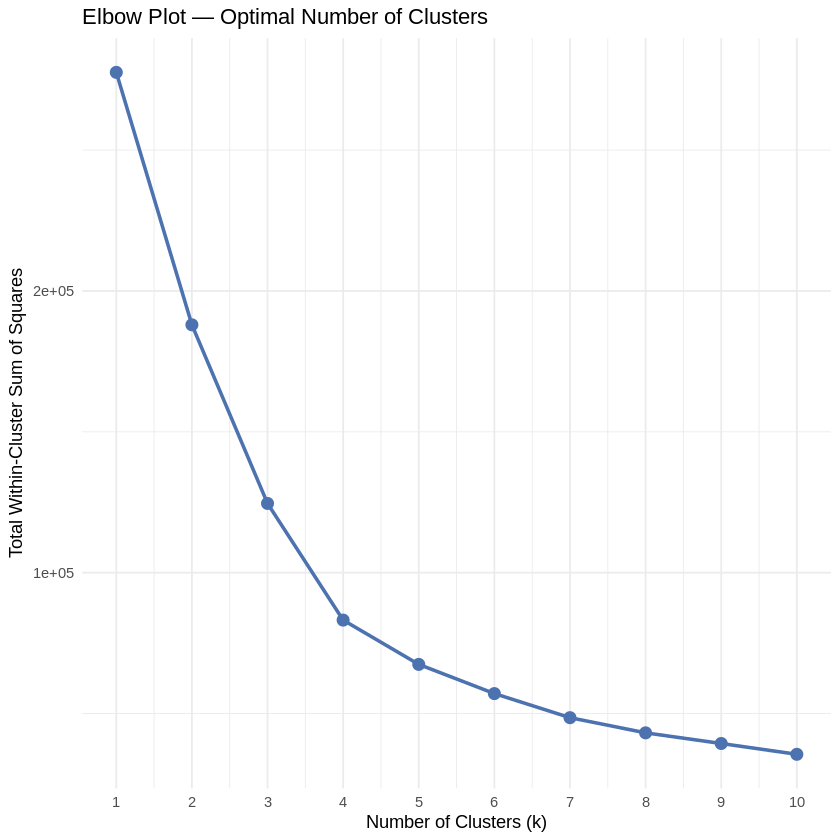

In [ ]:
# Scale the RFM variables
rfm_scaled <- rfm_clean %>%
  select(recency, log_frequency, log_monetary) %>%
  scale()

# Elbow plot
set.seed(42)
wss <- map_dbl(1:10, function(k) {
  kmeans(rfm_scaled, centers = k, nstart = 25)$tot.withinss
})

elbow_df <- data.frame(k = 1:10, wss = wss)

ggplot(elbow_df, aes(x = k, y = wss)) +
  geom_line(color = '#4C72B0', linewidth = 1) +
  geom_point(color = '#4C72B0', size = 3) +
  scale_x_continuous(breaks = 1:10) +
  labs(title = 'Elbow Plot — Optimal Number of Clusters',
       x = 'Number of Clusters (k)',
       y = 'Total Within-Cluster Sum of Squares') +
  theme_minimal()

### K-Means Clustering
The elbow plot shows the sharpest reduction in within-cluster sum of squares between k=1 and k=4, with diminishing gains beyond that point. We therefore proceed with k=4 clusters, corresponding to four distinct customer segments.

In [ ]:
set.seed(42)
km <- kmeans(rfm_scaled, centers = 4, nstart = 25)

rfm_clean$cluster <- as.factor(km$cluster)

# Profile each cluster
cluster_profile <- rfm_clean %>%
  group_by(cluster) %>%
  summarise(
    count = n(),
    avg_recency = round(mean(recency), 1),
    avg_frequency = round(mean(frequency), 2),
    avg_monetary = round(mean(monetary), 2)
  ) %>%
  arrange(avg_monetary %>% desc())

print(cluster_profile)

# A tibble: 4 × 5
  cluster count avg_recency avg_frequency avg_monetary
  <fct>   <int>       <dbl>         <dbl>        <dbl>
1 4        2634        271.           2.1        275. 
2 3       29756        218.           1          260. 
3 1       26457        476.           1          120. 
4 2       33688        199.           1           65.1


### Cluster Profiles
Four distinct customer segments emerged from k-means clustering:

*   Champions (2,634): Most engaged customers — highest frequency and spend, purchased relatively recently
*   Promising (29,756): Recent one-time buyers with solid spend — strong candidates for conversion to loyal customers
* At-Risk (26,457): Lapsed customers who haven't purchased in over 15 months on average — require re-engagement campaigns
* Casual Browsers (33,688): Recent but low-spend customers — largest segment, price-sensitive or still exploring

In [ ]:
rfm_clean$segment <- case_when(
  rfm_clean$cluster == 4 ~ 'Champions',
  rfm_clean$cluster == 3 ~ 'Promising',
  rfm_clean$cluster == 1 ~ 'At-Risk',
  rfm_clean$cluster == 2 ~ 'Casual Browsers'
)

table(rfm_clean$segment)


        At-Risk Casual Browsers       Champions       Promising 
          26457           33688            2634           29756 

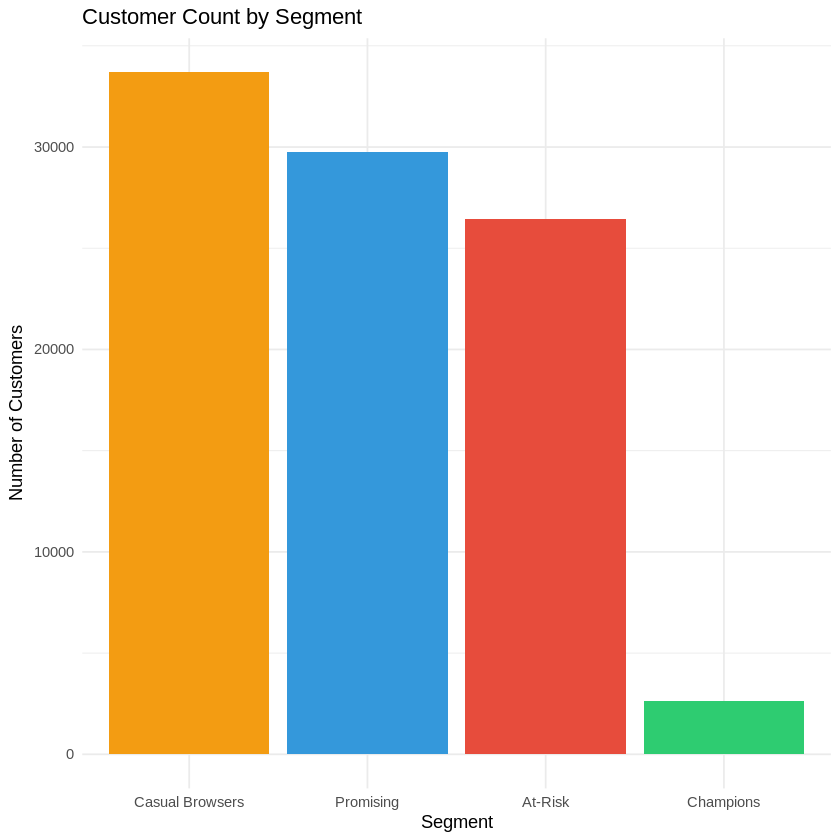

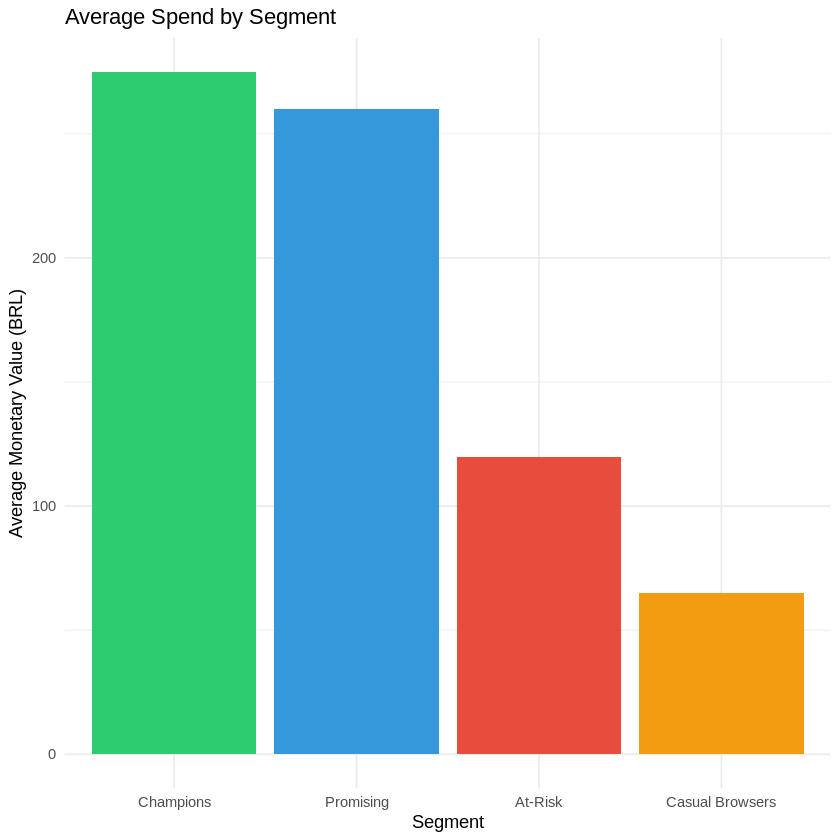

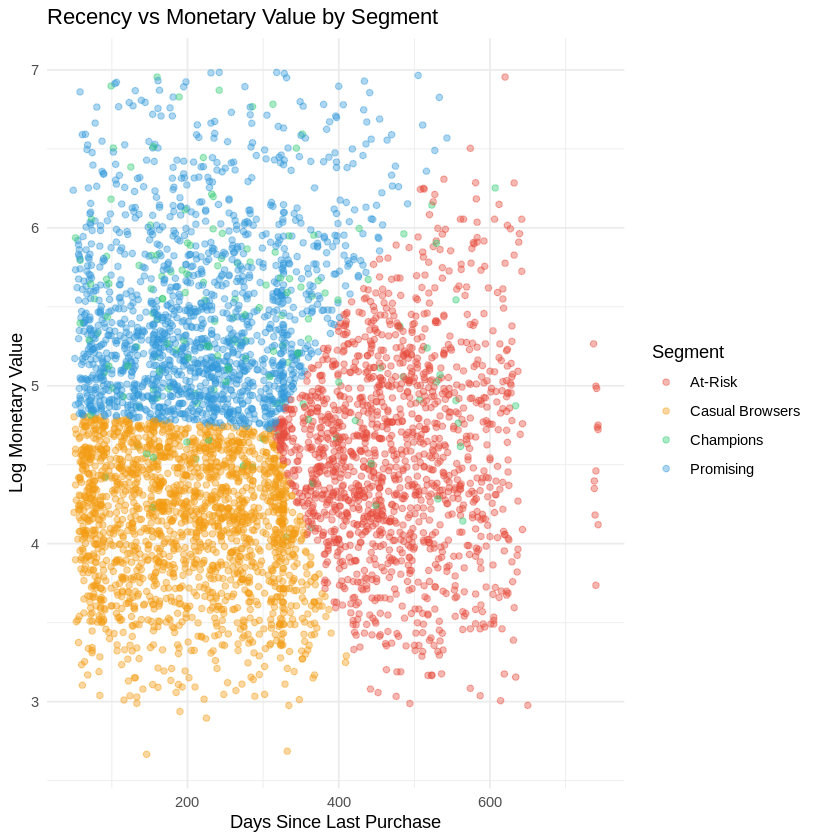

In [ ]:
# Bar chart - customer count by segment
p4 <- ggplot(rfm_clean, aes(x = reorder(segment, -table(segment)[segment]),
                             fill = segment)) +
  geom_bar() +
  scale_fill_manual(values = c(
    'Champions' = '#2ecc71',
    'Promising' = '#3498db',
    'At-Risk' = '#e74c3c',
    'Casual Browsers' = '#f39c12'
  )) +
  labs(title = 'Customer Count by Segment',
       x = 'Segment', y = 'Number of Customers') +
  theme_minimal() +
  theme(legend.position = 'none')

# Bar chart - average monetary by segment
p5 <- ggplot(rfm_clean %>%
               group_by(segment) %>%
               summarise(avg_spend = mean(monetary)),
             aes(x = reorder(segment, -avg_spend),
                 y = avg_spend, fill = segment)) +
  geom_col() +
  scale_fill_manual(values = c(
    'Champions' = '#2ecc71',
    'Promising' = '#3498db',
    'At-Risk' = '#e74c3c',
    'Casual Browsers' = '#f39c12'
  )) +
  labs(title = 'Average Spend by Segment',
       x = 'Segment', y = 'Average Monetary Value (BRL)') +
  theme_minimal() +
  theme(legend.position = 'none')

# Scatter plot - recency vs monetary coloured by segment
p6 <- ggplot(rfm_clean %>% sample_n(5000),
             aes(x = recency, y = log_monetary, color = segment)) +
  geom_point(alpha = 0.4, size = 1.5) +
  scale_color_manual(values = c(
    'Champions' = '#2ecc71',
    'Promising' = '#3498db',
    'At-Risk' = '#e74c3c',
    'Casual Browsers' = '#f39c12'
  )) +
  labs(title = 'Recency vs Monetary Value by Segment',
       x = 'Days Since Last Purchase',
       y = 'Log Monetary Value',
       color = 'Segment') +
  theme_minimal()

p4
p5
p6

### Segment Visualisations
**Customer Count by Segment**: Casual Browsers form the largest group (33,688) followed closely by Promising and At-Risk customers. Champions are the smallest segment at just 2,634 — typical of real-world customer bases where highly engaged buyers are a minority.

**Average Spend by Segment**: Champions and Promising customers spend roughly 4x more on average than Casual Browsers, confirming spend as a key differentiator between segments.

**Recency vs Monetary Scatter**: The segmentation is visually well-separated. Promising (blue) and Casual Browsers (orange) cluster on the left (recent buyers), split by spend level. At-Risk (red) sits on the right (lapsed buyers). Champions (green) are scattered but concentrated in the high-spend upper region.

In [ ]:
# Save segmented data
rfm_clean %>%
  select(customer_unique_id, customer_city, customer_state,
         recency, frequency, monetary, segment) %>%
  write.csv(paste0(data_path, 'rfm_segmented.csv'), row.names = FALSE)

cat("Saved rfm_segmented.csv successfully\n")
cat("Segment breakdown:\n")
print(table(rfm_clean$segment))

Saved rfm_segmented.csv successfully
Segment breakdown:

        At-Risk Casual Browsers       Champions       Promising 
          26457           33688            2634           29756 


### Summary & Next Steps
The k-means clustering successfully identified four actionable customer segments from 92,535 Olist customers:

Champions (2,634): Retain and reward — loyalty programs, early access to new products

Promising (29,756): Convert to loyal — follow-up emails, second purchase incentives

At-Risk (26,457): Re-engage — win-back campaigns, time-limited discounts

Casual Browsers (33,688): Upsell — targeted promotions based on their purchase category

The segmented dataset has been exported to rfm_segmented.csv for dashboard visualisation in Power BI.